In [27]:
import numpy as np
import agama
import pandas as pd
import h5py
import matplotlib.pyplot as plt
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm
from reverse_orbit import reverse_orbit
agama.setUnits(length=1, velocity=1, mass=1)  # kpc, km/s, Solar mass

import sys
sys.path.append('/suphys/aani0116/Work/minicluster_tidal/stellar')
from scipy.stats import uniform_direction


pot_mw = agama.Potential('/suphys/aani0116/minicluster/minicluster_tidal/Agama/data/McMillan17.ini')



In [28]:
class Minicluster:
    def __init__(self, mass, delta, concentration):
        self.mass          = mass
        self.delta         = delta
        self.concentration = concentration

        self.density = self._density()
        self.radius  = self._radius()
        self.radius_char = self.radius_char()
        self.density_char = self.density_char()


    def _density(self):
        return 2.4e6 * self.delta**3 * (1 + self.delta) * 3e7  #1Gev/cm3=3.10^7 Msun/kpc3

    def _radius(self):
        return (3 * self.mass / (4 * np.pi * self.density)) ** (1/3)

    def density_char(self):
        c = self.concentration
        return self.density * (c**3/3) / (np.log(1 + c) - c / (1 + c))
    
    def radius_char(self):
        c = self.concentration
        return self.radius / c
    
    def mass_within_radius(self, r):
        c = self.concentration
        r_char = self.radius_char 
        r_vir=self.radius
        cx=r/r_char
        return 4*np.pi*self.density_char*(r_vir/c)**3 * (np.log(1 + cx) - cx / (1 + cx)) 

    def potential(self, random_radius):
        return -agama.G*self.mass_within_radius(random_radius)/random_radius



In [29]:
mc = Minicluster(mass=1e-7, delta=10, concentration=10)
mc.radius

3.112161097789622e-09

In [24]:
mc = Minicluster(mass=1e-7, delta=10, concentration=10)
Nbody=1000

In [25]:
pot_mc = agama.Potential(
    type='Multipole',
    density='Spheroid',
    gamma=1, beta=3,alpha=1,cutoffStrength=1,
    scaleRadius=mc.radius_char,
    outerCutoffRadius=mc.radius,
    mass=mc.mass,
    rmin=0,
    rmax=0,
    gridSizeR=100,
    lmax=0,
)
df_mc   = agama.DistributionFunction(type='quasispherical', potential=pot_mc)
mcp_xv, mcp_mass = agama.GalaxyModel(pot_mc, df_mc).sample(Nbody)


In [26]:
pot_mc=agama.Potential(type='Multipole',particles=(mcp_xv, mcp_mass),symmetry='n',rmin=0,
    rmax=0,
    gridSizeR=100,
    lmax=0,)

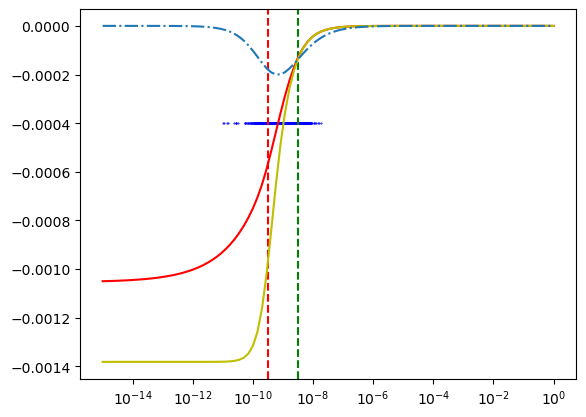

In [13]:
pot_plummer=agama.Potential(type='Plummer', mass=mc.mass, scaleRadius=mc.radius_char)
r_p=np.linalg.norm(mcp_xv[:,:3], axis=1)
r = np.logspace(-15, 0, 100)
xyz = np.column_stack([r, np.zeros_like(r), np.zeros_like(r)])
pot_m = pot_mc.potential(xyz) 
pot_p=pot_plummer.potential(xyz)  
plt.axvline(mc.radius_char, color='red', linestyle='--', label='Characteristic radius')
plt.axvline(mc.radius, color='green', linestyle='--', label='Virial radius')
plt.scatter(r_p, -0.0004 * np.ones_like(r_p), s=0.2,color='blue', label='Stream particles')
plt.plot(r, pot_m,'r')
plt.plot(r, pot_p,'y')
plt.plot(r,mc.potential(r),'-.')
plt.xscale('log')

In [49]:
bound=0.5*np.linalg.norm(mcp_xv[:, 3:6], axis=1)**2+pot_mc.potential(mcp_xv[:, :3])<0
print('Fraction of bound particles:',np.sum(bound)/len(bound))
print("Virial theorem -2KE/PE=", -np.sum(np.linalg.norm(mcp_xv[:, 3:6], axis=1)**2)/(0.5*np.sum(pot_mc.potential(mcp_xv[:, :3]))))

Fraction of bound particles: 1.0
Virial theorem -2KE/PE= 0.9965565749522464


Starting position: [ 7.3822284e+00  1.1455185e-01  1.3221530e+00 -6.9757858e+01
  1.0849174e+00  2.1734128e+02]


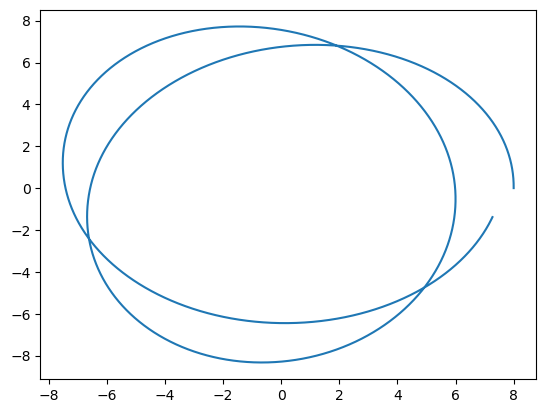

In [15]:

solar_pos = np.array([8.0, 0.0, 0.0, 2.0, 2.0, 220.0]) 
N_orbits=2
orbit_time = N_orbits *    pot_mw.Tcirc(solar_pos)

mc_center=reverse_orbit(solar_pos, pot_mw,N_orbits*pot_mw.Tcirc(solar_pos),6, 10)
s_orbit = agama.orbit(ic=solar_pos, potential=pot_mw, time=orbit_time,trajsize=10000,timestart= 0)
plt.plot(s_orbit[1][:,0], s_orbit[1][:,2])
plt.show()

In [51]:
#MC parameters
mcp_xv += mc_center 

In [52]:
#simulation parameters
simulation_time = orbit_time
tupd = 1e-3 # Gyr
time_i = 0



In [53]:
mc_t=[]
mc_xv=[]
bound   = np.ones(len(mcp_xv), dtype=bool) 
E_p=[]

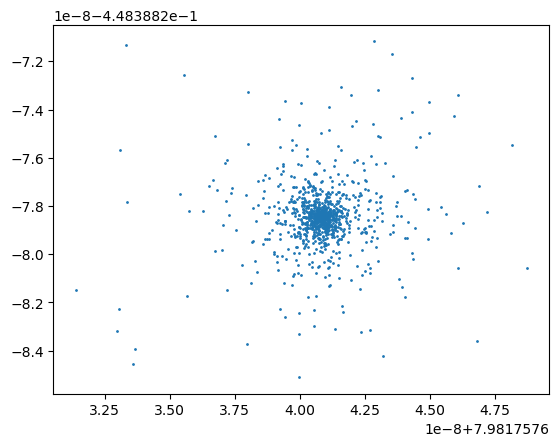

In [54]:
plt.scatter(mcp_xv[:, 0], mcp_xv[:, 2], s=1)

In [55]:
while time_i < simulation_time:

    mc_time_center, mc_orbit_center = agama.orbit(ic=mc_center, potential=pot_mw, time=tupd,timestart=time_i, trajsize=10, accuracy=1e-10)
    mc_t.extend([mc_time_center[-1]])
    mc_xv.append(mc_orbit_center[-1])



    pot_total = agama.Potential(pot_mw,agama.Potential(potential=pot_mc,center=np.column_stack((mc_time_center, mc_orbit_center))))

    mcp_xv = np.vstack(agama.orbit(ic=mcp_xv, potential=pot_total,time=tupd, timestart=time_i, trajsize=1, accuracy=1e-10)[:, 1])

    
    rel_pos = mcp_xv[:, :3] - mc_orbit_center[-1][:3]
    rel_vel = mcp_xv[:, 3:6] - mc_orbit_center[-1][3:6]
    pos_f   = mcp_xv[:, :3]
    vel_f   = mcp_xv[:, 3:6]

    E_p.append(0.5*np.linalg.norm(mcp_xv[:, 3:], axis=1)**2+0.5*pot_mc.potential(mcp_xv[:, :3]))
    bound=0.5*np.linalg.norm(rel_vel, axis=1)**2+pot_mc.potential(rel_pos)<0
    n_bound=np.sum(bound)

    if n_bound>10:
        pot_mc=agama.Potential(type='multipole',particles=(rel_pos[bound], mcp_mass[bound]),symmetry='n') 
    if n_bound<=10:
        pot_mc=agama.Potential(type='Plummer', mass=0.0, scaleRadius=1.0)

    

    
    
    mc_center = mc_orbit_center[-1]
    time_i += tupd
    plt.scatter(mcp_xv[:, 0], mcp_xv[:, 2], s=1)
mc_xv=np.array(mc_xv)
mc_t=np.array(mc_t)




1000 orbits complete (1.596 orbits/s)                


RuntimeError: Error in creating potential: Multipole: no massive particles at r=0 allowed

In [65]:
mc_time_center, mc_orbit_center = agama.orbit(ic=mc_center, potential=pot_mw, time=tupd,timestart=time_i, trajsize=10, accuracy=1e-10)



In [66]:
mc_orbit_center


array([[ 7.9817576e+00, -4.0871711e-03, -4.4838828e-01,  1.5805020e+01,
         1.9964778e+00,  2.1808507e+02],
       [ 7.9834723e+00, -3.8653195e-03, -4.2414746e-01,  1.5061742e+01,
         1.9968481e+00,  2.1824895e+02],
       [ 7.9851046e+00, -3.6434277e-03, -3.9988866e-01,  1.4317483e+01,
         1.9971980e+00,  2.1840837e+02],
       [ 7.9866543e+00, -3.4214985e-03, -3.7561244e-01,  1.3572268e+01,
         1.9975277e+00,  2.1856311e+02],
       [ 7.9881206e+00, -3.1995336e-03, -3.5131928e-01,  1.2826120e+01,
         1.9978369e+00,  2.1871286e+02],
       [ 7.9895043e+00, -2.9775354e-03, -3.2700977e-01,  1.2079071e+01,
         1.9981258e+00,  2.1885736e+02],
       [ 7.9908047e+00, -2.7555064e-03, -3.0268452e-01,  1.1331148e+01,
         1.9983940e+00,  2.1899625e+02],
       [ 7.9920225e+00, -2.5334486e-03, -2.7834415e-01,  1.0582387e+01,
         1.9986418e+00,  2.1912910e+02],
       [ 7.9931564e+00, -2.3113645e-03, -2.5398940e-01,  9.8328218e+00,
         1.9988691e+00, 

In [64]:
mc_orbit_center

array([[ 7.98175764e+00, -4.08717105e-03, -4.48388278e-01,
         1.58050203e+01,  1.99647784e+00,  2.18085068e+02],
       [ 7.98347247e+00, -3.86531942e-03, -4.24147460e-01,
         1.50617418e+01,  1.99684808e+00,  2.18248947e+02],
       [ 7.98510466e+00, -3.64342779e-03, -3.99888677e-01,
         1.43174829e+01,  1.99719804e+00,  2.18408373e+02],
       [ 7.98665410e+00, -3.42149839e-03, -3.75612440e-01,
         1.35722672e+01,  1.99752768e+00,  2.18563103e+02],
       [ 7.98812068e+00, -3.19953350e-03, -3.51319283e-01,
         1.28261205e+01,  1.99783693e+00,  2.18712867e+02],
       [ 7.98950431e+00, -2.97753539e-03, -3.27009775e-01,
         1.20790707e+01,  1.99812574e+00,  2.18857361e+02],
       [ 7.99080489e+00, -2.75550632e-03, -3.02684522e-01,
         1.13311483e+01,  1.99839406e+00,  2.18996241e+02],
       [ 7.99202231e+00, -2.53344858e-03, -2.78344167e-01,
         1.05823866e+01,  1.99864184e+00,  2.19129111e+02],
       [ 7.99315650e+00, -2.31136445e-03, -2.539

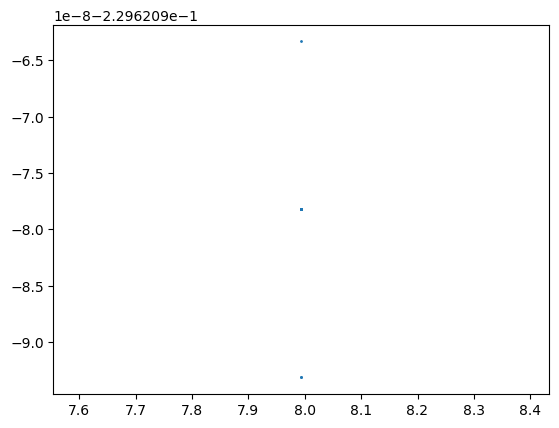

In [58]:
plt.scatter(mcp_xv[:,0], mcp_xv[:,2], s=1)

In [ ]:
#plt.scatter(mc_xv[:,0], mc_xv[:,2],color='red')
plt.scatter(mcp_xv[:,0], mcp_xv[:,2], s=1, color='blue')
plt.show()

In [ ]:
with h5py.File('mc.h5', 'w') as f:
        f.create_dataset('mcp_xv', data=mcp_xv)
        f.create_dataset('mc_xv',  data=mc_xv)
        f.create_dataset('mc_t',   data=mc_t)
        f.attrs['mcp_mass'] = mcp_mass
        f.attrs['mc_mass'] = mc.mass
        f.attrs['mc_radius'] = mc.radius
        f.attrs['mc_radius_char'] = mc.radius_char
        f.attrs['mc_density'] = mc.density
        f.attrs['mc_density_char'] = mc.density_char
        f.attrs['mc_concentration'] = mc.concentration


In [ ]:
with h5py.File('mc.h5', 'r') as f:
    mcp_xv = f['mcp_xv'][:]
    mc_xv  = f['mc_xv'][:]
    mc_t   = f['mc_t'][:]


In [ ]:
mc_xv

In [ ]:
import os
os.getcwd()


In [48]:
import h5py, glob

files = glob.glob('/suphys/aani0116/Work/minicluster_tidal/hpc/*.h5')


In [49]:
files

['/suphys/aani0116/Work/minicluster_tidal/hpc/mc6_m1.0e-06_c10_d10.h5',
 '/suphys/aani0116/Work/minicluster_tidal/hpc/mc4_m1.0e-06_c10_d10.h5']

In [50]:
with h5py.File(files[1], 'r') as f:
    mcp_xv     = f['mcp_xv'][:]
    bound      = f['bound'][:]
    E_p        = f['E_p'][:]
    mc_xv      = f['mc_xv'][:]
    snap_times = f['snap_times'][:]
    
    mcp_mass        = f.attrs['mcp_mass']
    Nbody           = f.attrs['Nbody']
    simulation_time = f.attrs['simulation_time']
    tupd            = f.attrs['tupd']
    N_orbits        = f.attrs['N_orbits']
    mc_mass         = f.attrs['mc_mass']
    mc_delta        = f.attrs['mc_delta']
    mc_radius       = f.attrs['mc_radius']
    mc_radius_char  = f.attrs['mc_radius_char']
    mc_density_char = f.attrs['mc_density_char']
    mc_concentration= f.attrs['mc_concentration']


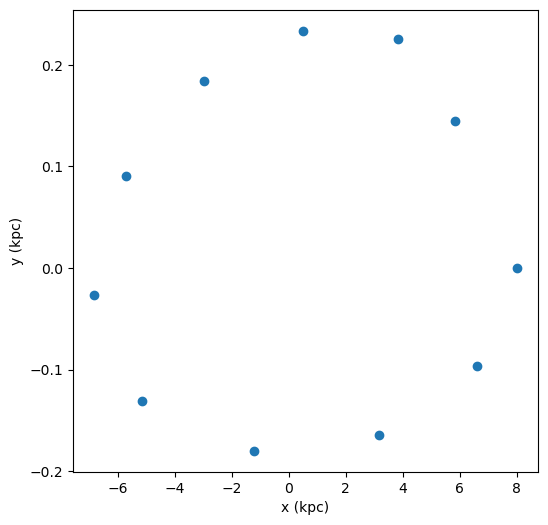

In [24]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(mc_xv[:, 0], mc_xv[:, 1])
ax.set_xlabel('x (kpc)')
ax.set_ylabel('y (kpc)')
plt.show()


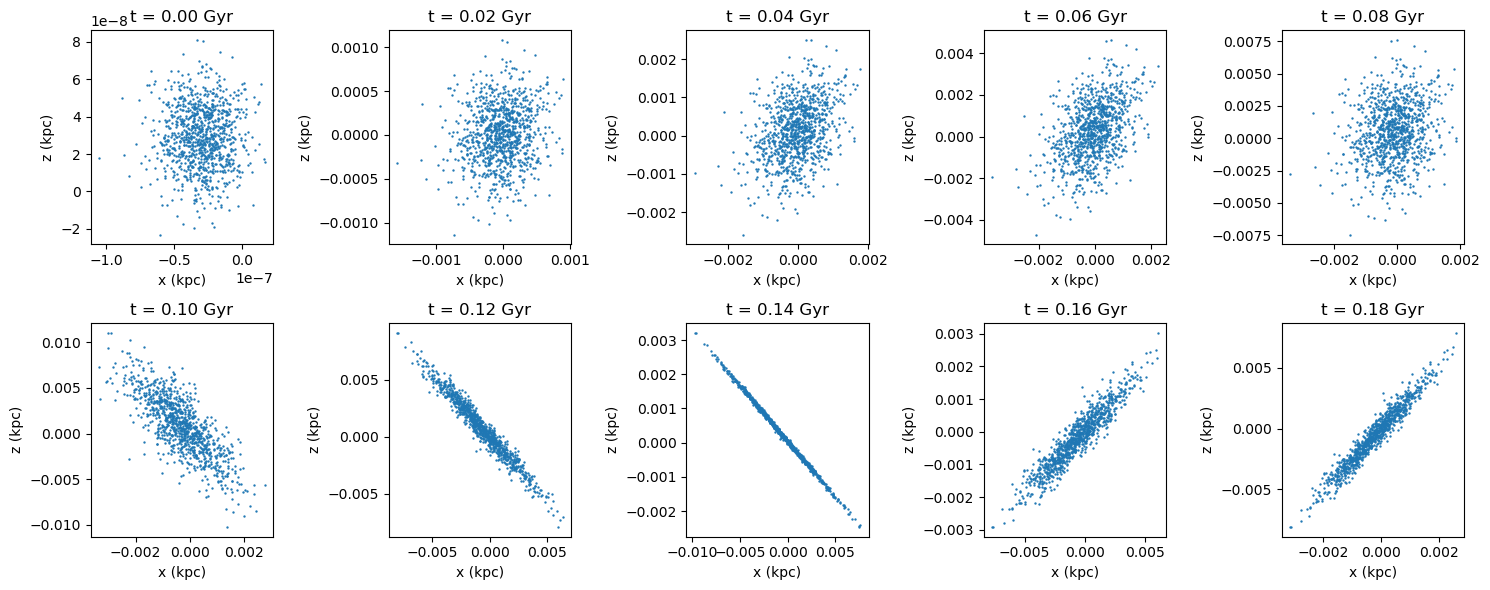

1e-06


In [25]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    ax.scatter(mcp_xv[i, :, 0], mcp_xv[i, :, 2], s=0.5)
    ax.set_title(f't = {snap_times[i]:.2f} Gyr')
    ax.set_xlabel('x (kpc)')
    ax.set_ylabel('z (kpc)')

plt.tight_layout()
plt.show()
print(tupd)

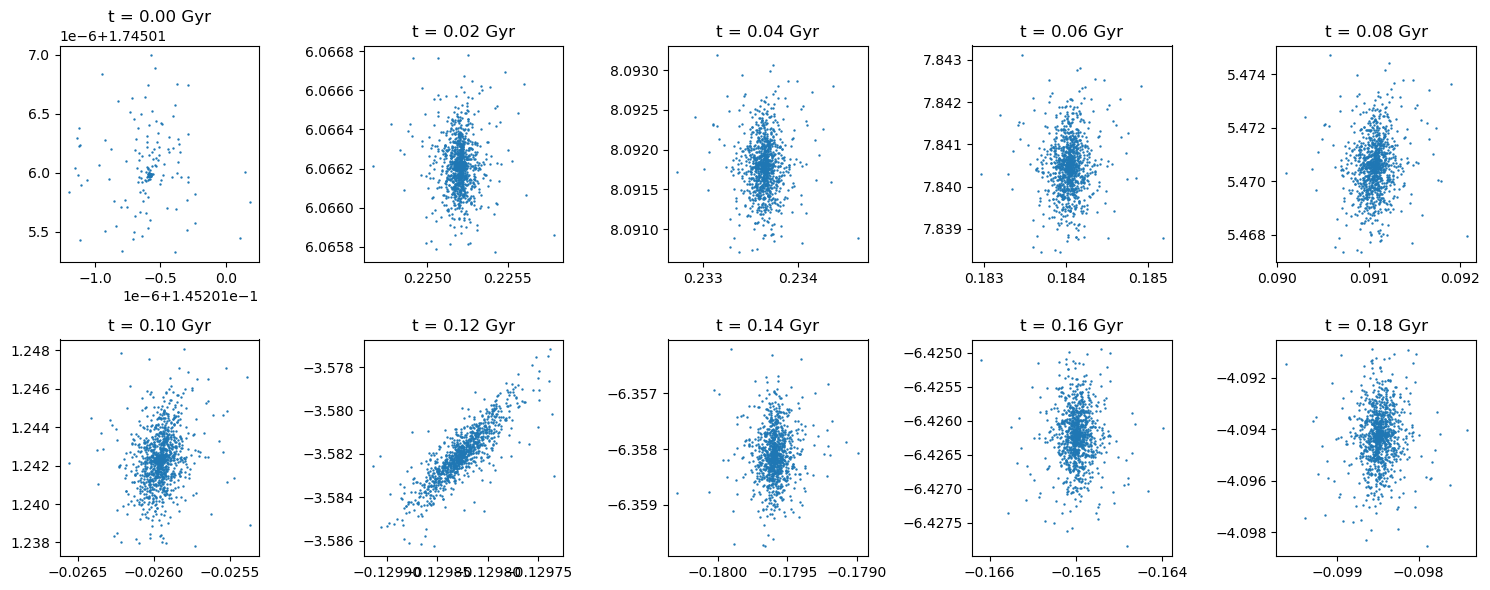

0.0001


In [62]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    ax.scatter(mcp_xv[i, :, 1]+mc_xv[i, 1], mcp_xv[i, :, 2]+mc_xv[i, 2], s=0.5)
    ax.set_title(f't = {snap_times[i]:.2f} Gyr')

plt.tight_layout()
plt.show()
print(tupd)


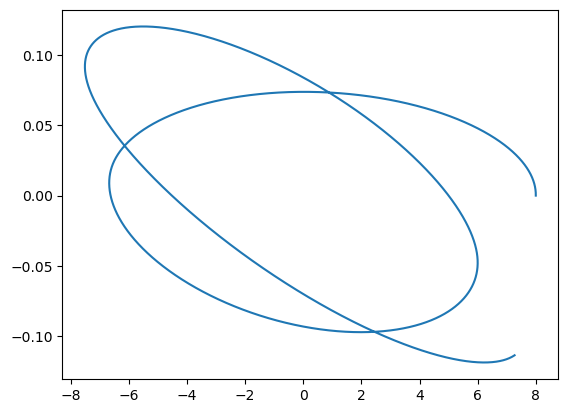

In [43]:
plt.plot(s_orbit[1][:,0], s_orbit[1][:,1])


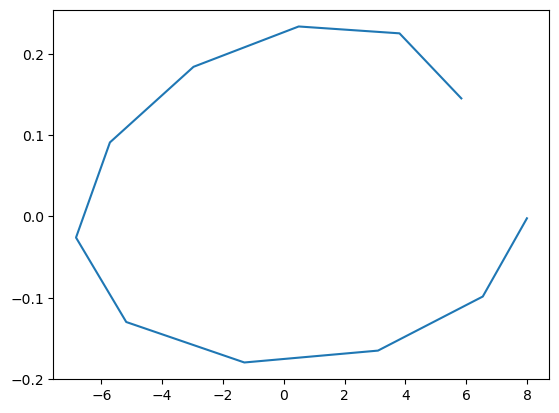

In [44]:
plt.plot(mc_xv[:,0], mc_xv[:,1])

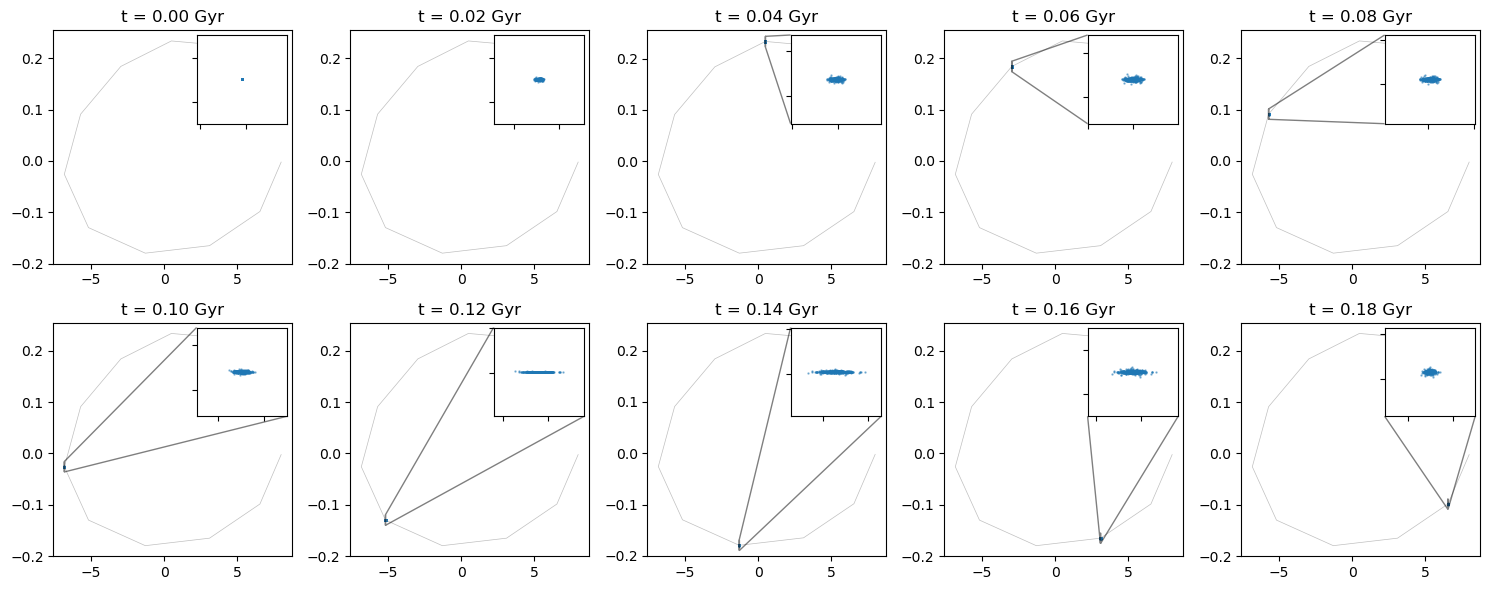

0.0001


In [64]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    # Full orbit as context
    ax.plot(mc_xv[:, 0], mc_xv[:, 1], lw=0.5, color='gray', alpha=0.5)
    ax.scatter(mcp_xv[i, :, 0]+mc_xv[i, 0], mcp_xv[i, :, 1]+mc_xv[i, 1], s=0.5, alpha=0.5)
    ax.set_title(f't = {snap_times[i]:.2f} Gyr')

    # Inset zoomed into particle region
    axz = ax.inset_axes([0.6, 0.6, 0.38, 0.38])
    axz.scatter(mcp_xv[i, :, 0]+mc_xv[i, 0], mcp_xv[i, :, 1]+mc_xv[i, 1], s=0.5, alpha=0.5)

    # Auto-set inset limits around particle cloud
    x_c = mcp_xv[i, :, 0].mean() + mc_xv[i, 0]
    y_c = mcp_xv[i, :, 1].mean() + mc_xv[i, 1]
    dx = max(mcp_xv[i, :, 0].std() * 4, 0.01)
    dy = max(mcp_xv[i, :, 1].std() * 4, 0.01)
    axz.set_xlim(x_c - dx, x_c + dx)
    axz.set_ylim(y_c - dy, y_c + dy)
    axz.set_xticklabels([])
    axz.set_yticklabels([])

    ax.indicate_inset_zoom(axz, edgecolor='black')

plt.tight_layout()
plt.show()
print(tupd)


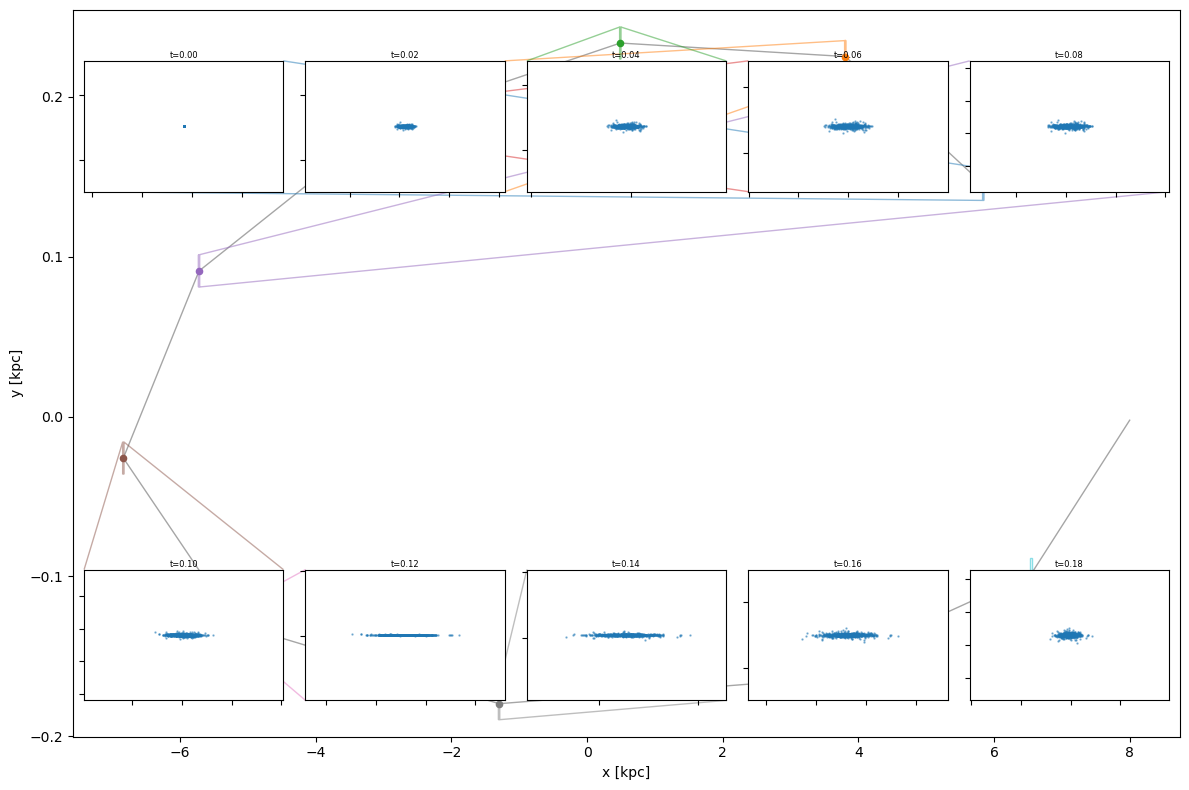

In [65]:
fig, ax = plt.subplots(figsize=(12, 8))

# Main plot: full orbit trajectory
ax.plot(mc_xv[:, 0], mc_xv[:, 1], lw=1, color='gray', alpha=0.7)
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')

# Place insets around the edges — adjust positions as needed
inset_positions = [
    [0.01, 0.75, 0.18, 0.18],
    [0.21, 0.75, 0.18, 0.18],
    [0.41, 0.75, 0.18, 0.18],
    [0.61, 0.75, 0.18, 0.18],
    [0.81, 0.75, 0.18, 0.18],
    [0.01, 0.05, 0.18, 0.18],
    [0.21, 0.05, 0.18, 0.18],
    [0.41, 0.05, 0.18, 0.18],
    [0.61, 0.05, 0.18, 0.18],
    [0.81, 0.05, 0.18, 0.18],
]

for i, pos in enumerate(inset_positions):
    axz = ax.inset_axes(pos)
    axz.scatter(mcp_xv[i, :, 0]+mc_xv[i, 0], mcp_xv[i, :, 1]+mc_xv[i, 1], s=0.5, alpha=0.5)
    axz.set_title(f't={snap_times[i]:.2f}', fontsize=6, pad=2)

    # Set zoom limits around particle cloud
    x_c = mcp_xv[i, :, 0].mean() + mc_xv[i, 0]
    y_c = mcp_xv[i, :, 1].mean() + mc_xv[i, 1]
    dx = max(mcp_xv[i, :, 0].std() * 4, 0.01)
    dy = max(mcp_xv[i, :, 1].std() * 4, 0.01)
    axz.set_xlim(x_c - dx, x_c + dx)
    axz.set_ylim(y_c - dy, y_c + dy)
    axz.set_xticklabels([])
    axz.set_yticklabels([])

    # Mark the snapshot position on the orbit
    ax.scatter(mc_xv[i, 0], mc_xv[i, 1], s=20, zorder=5)
    ax.indicate_inset_zoom(axz, edgecolor='C' + str(i % 10))

plt.tight_layout()
plt.show()


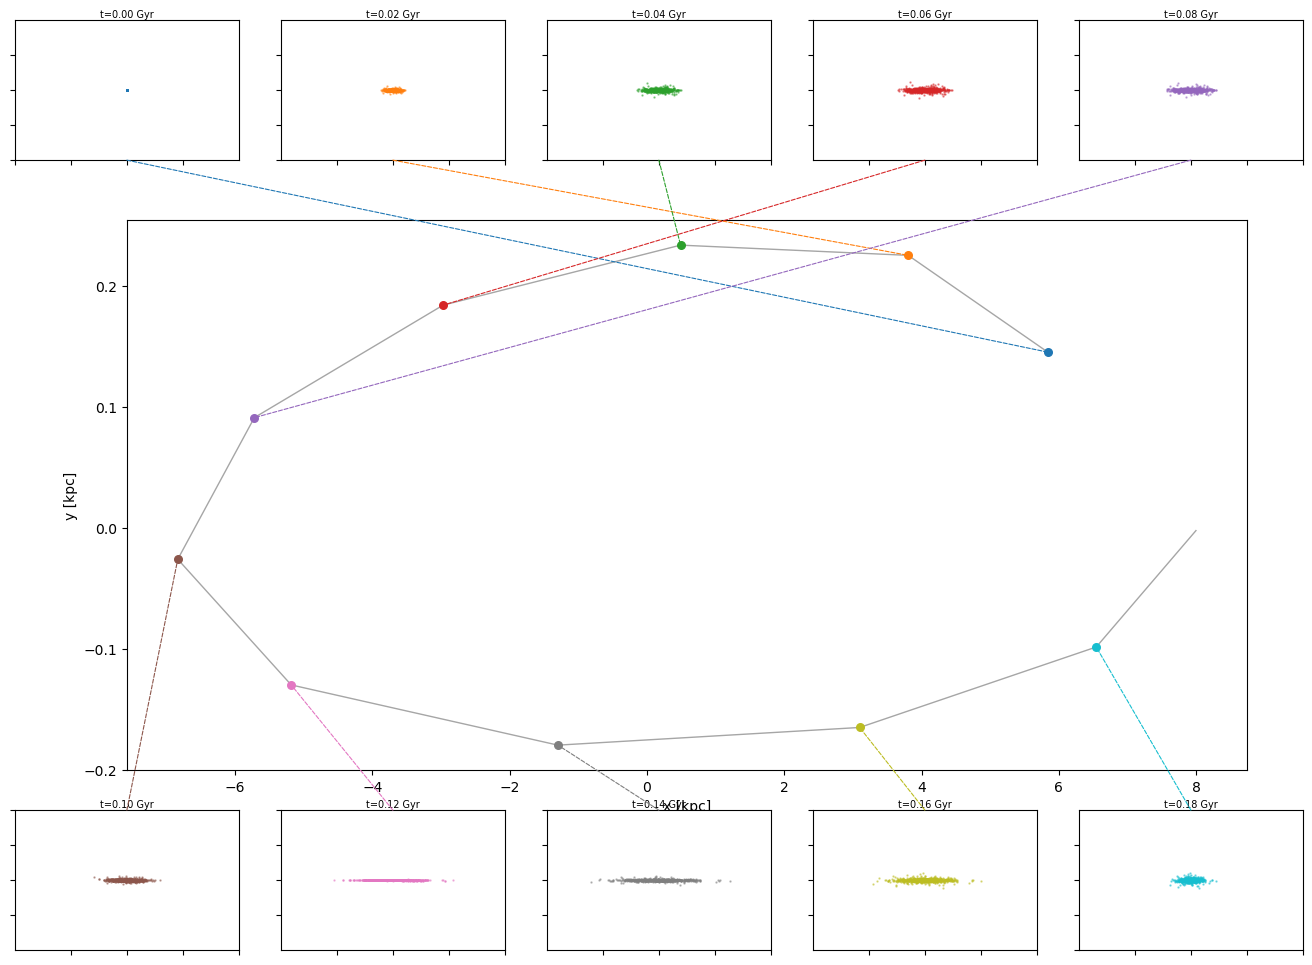

In [66]:
from matplotlib.patches import ConnectionPatch

fig = plt.figure(figsize=(14, 10))

# Main axes — leave margins top and bottom for thumbnails
ax = fig.add_axes([0.1, 0.22, 0.8, 0.55])
ax.plot(mc_xv[:, 0], mc_xv[:, 1], lw=1, color='gray', alpha=0.7)
ax.set_xlabel('x [kpc]')
ax.set_ylabel('y [kpc]')

# 5 thumbnails above, 5 below — evenly spaced in figure coords
x_starts = [0.02, 0.21, 0.40, 0.59, 0.78]
thumb_w, thumb_h = 0.16, 0.14

top_pos    = [[x, 0.83, thumb_w, thumb_h] for x in x_starts]
bottom_pos = [[x, 0.04, thumb_w, thumb_h] for x in x_starts]
positions  = top_pos + bottom_pos

for i, pos in enumerate(positions):
    axz = fig.add_axes(pos)
    axz.scatter(mcp_xv[i, :, 0], mcp_xv[i, :, 1], s=0.5, alpha=0.5, color=f'C{i}')
    axz.set_title(f't={snap_times[i]:.2f} Gyr', fontsize=7, pad=2)

    x_c = mcp_xv[i, :, 0].mean()
    y_c = mcp_xv[i, :, 1].mean()
    dx  = max(mcp_xv[i, :, 0].std() * 4, 0.01)
    dy  = max(mcp_xv[i, :, 1].std() * 4, 0.01)
    axz.set_xlim(x_c - dx, x_c + dx)
    axz.set_ylim(y_c - dy, y_c + dy)
    axz.tick_params(labelbottom=False, labelleft=False)

    # Mark snapshot location on main orbit
    ax.scatter(mc_xv[i, 0], mc_xv[i, 1], s=30, color=f'C{i}', zorder=5)

    # Connector: bottom of top thumbnails, top of bottom thumbnails
    xy_thumb = (0.5, 0.0) if i < 5 else (0.5, 1.0)

    con = ConnectionPatch(
        xyA=xy_thumb, coordsA='axes fraction', axesA=axz,
        xyB=(mc_xv[i, 0], mc_xv[i, 1]), coordsB='data', axesB=ax,
        color=f'C{i}', lw=0.8, linestyle='--'
    )
    fig.add_artist(con)

plt.show()


In [61]:
mc_xv[0,0]

np.float32(5.839175)